# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 3B — Transfer Learning with DenseNet121

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Backbone:** DenseNet121 — Huang et al. (2017). *Densely Connected Convolutional Networks.* CVPR. https://doi.org/10.1109/CVPR.2017.243

> All training hyperparameters are **identical** across NB03A, NB03B, and NB03C. DenseNet121 is the backbone of **CheXNet** (Rajpurkar et al., 2017), the landmark model that first achieved radiologist-level pneumonia detection.

| Phase | Config | Duration |
|-------|--------|----------|
| 1 — Feature extraction | Backbone frozen, lr=1e-3 | 10 epochs |
| 2 — Fine-tuning | Last 80 layers unfrozen, lr=1e-5 | up to 20 epochs |

---

---
## 1. Environment Setup

In [1]:
import os, warnings, random, json, time, math
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger, LearningRateScheduler
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4

print('TensorFlow:', tf.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU'))

2026-05-18 09:14:40.950677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779095681.175804      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779095681.235135      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779095681.763316      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779095681.763355      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779095681.763358      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## 2. Configuration

All hyperparameters are **identical** across NB03A, NB03B, and NB03C. The only variable that differs is the CNN backbone architecture.

In [2]:
# ─── Paths (Kaggle) ──────────────────────────────────────────────────────────
BASE_PATH  = '/kaggle/input/datasets/ashery/chexpert'
OUT_DIR    = '/kaggle/working'
MODEL_NAME = 'densenet121'

# ─── Image & batch ────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# ─── Dataset split sizes ──────────────────────────────────────────────────────
TRAIN_SIZE = 50000
VAL_SIZE   = 5000
TEST_SIZE  = 5000

# ─── Training hyperparameters — identical across NB03A, NB03B, NB03C ─────────
EPOCHS_P1        = 10
EPOCHS_P2        = 20
LR_P1            = 1e-3
LR_P2            = 1e-5
ES_PATIENCE      = 8
LABEL_SMOOTH_EPS = 0.05
UNFREEZE_N       = 80  # last 80 of 427 layers (dense_block4)

# ─── Labels ───────────────────────────────────────────────────────────────────
LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]
NUM_CLASSES = len(LABEL_COLS)

print('Model      :', MODEL_NAME)
print('Unfreeze   : last 80 layers (DenseNet121 dense_block4)')
print('Train size :', TRAIN_SIZE)

Model      : densenet121
Unfreeze   : last 80 layers (DenseNet121 dense_block4)
Train size : 50000


---
## 3. Load & Prepare Data

**U-Mixed uncertainty strategy:** U-Ones for Edema, Atelectasis, Pleural Effusion, and Cardiomegaly — maximises sensitivity for high-cost missed detections. U-Zeros for all remaining labels.

In [3]:
train_raw = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
valid_raw = pd.read_csv(os.path.join(BASE_PATH, 'valid.csv'))

# Frontal views only
train_frontal = train_raw[train_raw['Frontal/Lateral'] == 'Frontal'].copy()

# U-Mixed uncertainty strategy
# U-Ones for clinically critical labels, U-Zeros for the rest
U_ONES = ['Edema', 'Atelectasis', 'Pleural Effusion', 'Cardiomegaly']
for col in LABEL_COLS:
    fill = 1.0 if col in U_ONES else 0.0
    train_frontal[col] = train_frontal[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)
    valid_raw[col]     = valid_raw[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)

# Build full paths
def add_path(df):
    df = df.copy()
    df['full_path'] = df['Path'].str.replace(
        'CheXpert-v1.0-small/', '', regex=False
    ).apply(lambda p: os.path.join(BASE_PATH, p))
    return df

train_frontal = add_path(train_frontal)
gold_df       = add_path(valid_raw)

# Stratified 80/10/10 split — identical across NB03A, NB03B, NB03C
tr_all, tmp = train_test_split(
    train_frontal, test_size=0.20, random_state=SEED,
    stratify=train_frontal['Pleural Effusion']
)
val_all, te_all = train_test_split(
    tmp, test_size=0.50, random_state=SEED,
    stratify=tmp['Pleural Effusion']
)

train_df = tr_all.sample(n=min(TRAIN_SIZE, len(tr_all)), random_state=SEED).reset_index(drop=True)
val_df   = val_all.sample(n=min(VAL_SIZE,  len(val_all)),  random_state=SEED).reset_index(drop=True)
test_df  = te_all.sample(n=min(TEST_SIZE,  len(te_all)),   random_state=SEED).reset_index(drop=True)

# Class weights for imbalanced labels
N = len(train_df)
pos_weights = np.array(
    [(N - train_df[c].sum()) / max(train_df[c].sum(), 1) for c in LABEL_COLS],
    dtype=np.float32
)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df), '| Gold:', len(gold_df))
print('Sample path exists:', os.path.exists(train_df['full_path'].iloc[0]))

Train: 50000 | Val: 5000 | Test: 5000 | Gold: 234
Sample path exists: True


---
## 4. tf.data Pipeline

4-operation augmentation pipeline: RandomFlip, RandomRotation, RandomZoom, RandomContrast. `RandomBrightness` excluded — causes GPU sync overhead. Pipeline is identical across NB03A, NB03B, NB03C.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation: 4 ops — fast, no RandomBrightness which causes slow GPU sync
augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom((-0.08, 0.08)),
    layers.RandomContrast(0.10),
], name='augmentation')


def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.repeat(img, 3, axis=-1)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment_fn(img, label):
    img = augment_layer(tf.expand_dims(img, 0), training=True)[0]
    return tf.clip_by_value(img, 0.0, 1.0), label


def make_ds(df, augment=False, shuffle=False):
    paths  = df['full_path'].values
    labels = df[LABEL_COLS].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8000, seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, augment=True,  shuffle=True)
val_ds   = make_ds(val_df,   augment=False, shuffle=False)
test_ds  = make_ds(test_df,  augment=False, shuffle=False)
gold_ds  = make_ds(gold_df,  augment=False, shuffle=False)

print('train_ds:', len(train_df), '->', len(train_df)//BATCH_SIZE, 'batches/epoch')
print('val_ds  :', len(val_df))
print('test_ds :', len(test_df))
print('gold_ds :', len(gold_df))

I0000 00:00:1779095710.598424      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779095710.604654      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds: 50000 -> 1562 batches/epoch
val_ds  : 5000
test_ds : 5000
gold_ds : 234


---
## 5. Model Architecture — DenseNet121

DenseNet121 (Huang et al., 2017) connects each layer to every other layer: each layer receives feature maps from all preceding layers and passes its own feature maps to all subsequent layers. This dense connectivity promotes feature reuse and strengthens gradient flow without skip connections. 121 weight layers, ~7M parameters, pre-trained on ImageNet.

```
DenseNet121 base (ImageNet, frozen in Phase 1)
  └─ GlobalAveragePooling2D
      └─ Dense(512, relu) + BatchNorm + Dropout(0.5)
          └─ Dense(256, relu) + BatchNorm + Dropout(0.3)
              └─ Dense(14, sigmoid)   ← 14 pathologies
```

> Head architecture is **identical** across NB03A, NB03B, NB03C.

In [5]:
def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
    base = DenseNet121(
        include_top=False, weights='imagenet',
        input_tensor=inputs, pooling=None
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(256, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    out = layers.Dense(NUM_CLASSES, activation='sigmoid', name='predictions')(x)
    return Model(inputs, out, name='DenseNet121_CheXpert'), base

model, base_model = build_model()
tr = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
nt = sum(int(np.prod(v.shape)) for v in model.non_trainable_variables)
print('Total params   :', model.count_params())
print('Trainable P1   :', tr, '(head only)')
print('Non-trainable  :', nt, '(frozen backbone)')
print('Backbone layers:', len(base_model.layers))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params   : 7700302
Trainable P1   : 661262 (head only)
Non-trainable  : 7039044 (frozen backbone)
Backbone layers: 427


---
## 6. Loss Function — Weighted BCE with Label Smoothing

Combines class-weighted binary cross-entropy (corrects label imbalance) with label smoothing ε=0.05 (Szegedy et al., 2016). Identical across all notebooks.

In [6]:
def build_loss(pos_weights, eps=LABEL_SMOOTH_EPS):
    pw  = tf.constant(pos_weights, dtype=tf.float32)
    eps = tf.constant(eps, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        ys = y_true * (1.0 - eps) + 0.5 * eps
        yp = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        return tf.reduce_mean(
            -(pw * ys * tf.math.log(yp) + (1.0 - ys) * tf.math.log(1.0 - yp))
        )
    return loss_fn

loss_fn = build_loss(pos_weights)
print('Loss ready. Label smoothing eps =', LABEL_SMOOTH_EPS)

Loss ready. Label smoothing eps = 0.05


---
## 7. Callbacks

ModelCheckpoint saves best `val_auc`. EarlyStopping patience=8 prevents premature stopping. Phase 2 adds cosine LR annealing (Loshchilov & Hutter, 2017).

In [7]:
CKPT = os.path.join(OUT_DIR, MODEL_NAME + '_best.h5')


def cosine_lr(epoch, lr):
    cos = 0.5 * (1.0 + math.cos(math.pi * epoch / max(EPOCHS_P2 - 1, 1)))
    return float(1e-8 + (LR_P2 - 1e-8) * cos)


def get_callbacks(phase):
    cbs = [
        ModelCheckpoint(CKPT, monitor='val_auc', mode='max',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_auc', mode='max',
                      patience=ES_PATIENCE, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-8, verbose=1),
        CSVLogger(os.path.join(OUT_DIR, MODEL_NAME + '_p' + str(phase) + '.csv')),
    ]
    if phase == 2:
        cbs.append(LearningRateScheduler(cosine_lr, verbose=0))
    return cbs

print('Checkpoint:', CKPT)

Checkpoint: /kaggle/working/densenet121_best.h5


---
## 8. Phase 1 — Feature Extraction

Backbone fully frozen. Only the classification head is trained for 10 epochs. Expected: ~1s/step on Kaggle T4.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_P1), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

print('Phase 1 | backbone fully frozen | lr =', LR_P1)
print('Batches/epoch:', len(train_df) // BATCH_SIZE)
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P1, callbacks=get_callbacks(1), verbose=1)
print('P1 done in', round((time.time()-t0)/60, 1), 'min')
print('Best val_auc P1:', round(max(h1.history['val_auc']), 4))

Phase 1 | backbone fully frozen | lr = 0.001
Batches/epoch: 1562
Epoch 1/10


I0000 00:00:1779095729.242671      71 service.cc:152] XLA service 0x7d9650292290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779095729.242713      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779095729.242718      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779095733.071629      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1563 ━━━━━━━━━━━━━━━━━━━━ 13:01:07 30s/step - acc: 0.4710 - auc: 0.4444 - loss: 1.7345

I0000 00:00:1779095746.200068      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - acc: 0.4226 - auc: 0.5914 - loss: 1.3725
Epoch 1: val_auc improved from -inf to 0.67150, saving model to /kaggle/working/densenet121_best.h5


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - acc: 0.4021 - auc: 0.6536 - loss: 1.2618 - val_acc: 0.4111 - val_auc: 0.6838 - val_loss: 1.2478 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - acc: 0.4039 - auc: 0.6663 - loss: 1.2523
Epoch 3: val_auc improved from 0.68378 to 0.68701, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 368s 236ms/step - acc: 0.4039 - auc: 0.6663 - loss: 1.2523 - val_acc: 0.4263 - val_auc: 0.6870 - val_loss: 1.2502 - learning_rate: 0.0010
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - acc: 0.4077 - auc: 0.6759 - loss: 1.2464
Epoch 4: val_auc improved from 0.68701 to 0.69159, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - acc: 0.4077 - auc: 0.6759 - loss: 1.2464 - val_acc: 0.4221 - val_auc: 0.6916 - val_loss: 1.2451 - learning_rate: 0.0010
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - acc: 0.4095 - auc: 0.6802 - loss: 1.2429
Epoch 5: val_auc did not improve from 0.69159
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 368s 235ms/step - acc: 0.4095 - auc: 0.6802 - loss: 1.2429 - val_acc: 0.4124 - val_auc: 0.6904 - val_loss: 1.2468 - learning_rate: 0.0010
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4113 - auc: 0.6847 - loss: 1.2404
Epoch 6: val_auc did not improve from 0.69159
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 384s 237ms/step - acc: 0.4113 - auc: 0.6847 - loss: 1.2404 - val_acc: 0.4140 - val_auc: 0.6914 - val_loss: 1.2407 - learning_rate: 0.0010
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4175 - auc: 0.6920 - loss: 1.2377
Epoch 7: val_auc improved from 0.69159 to 0.69449, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 371s 237ms/step - acc: 0.4175 - auc: 0.6920 - loss: 1.2377 - val_acc: 0.4110 - val_auc: 0.6945 - val_loss: 1.2427 - learning_rate: 0.0010
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4158 - auc: 0.6921 - loss: 1.2365
Epoch 8: val_auc improved from 0.69449 to 0.69842, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - acc: 0.4158 - auc: 0.6921 - loss: 1.2365 - val_acc: 0.4113 - val_auc: 0.6984 - val_loss: 1.2384 - learning_rate: 0.0010
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4138 - auc: 0.6950 - loss: 1.2398
Epoch 9: val_auc did not improve from 0.69842
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - acc: 0.4138 - auc: 0.6950 - loss: 1.2398 - val_acc: 0.4095 - val_auc: 0.6951 - val_loss: 1.2420 - learning_rate: 0.0010
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4180 - auc: 0.6988 - loss: 1.2342
Epoch 10: val_auc did not improve from 0.69842
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - acc: 0.4180 - auc: 0.6988 - loss: 1.2342 - val_acc: 0.4123 - val_auc: 0.6965 - val_loss: 1.2429 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.
P1 done in 63.9 min
Best val_auc P1: 0.6984


---
## 9. Phase 2 — Fine-Tuning

Last 80 layers of DenseNet121 unfrozen — dense_block4 and transition layer. These encode the highest-level pathology-specific features.

| DenseNet block | Phase 2 |
|----------------|---------|
| dense_block1–3, transition1–2 | Frozen |
| dense_block4 (last 80 layers) | Unfrozen |

In [9]:
# Unfreeze last 80 layers — DenseNet121 dense_block4
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

n_frozen   = sum(1 for l in base_model.layers if not l.trainable)
n_unfrozen = sum(1 for l in base_model.layers if l.trainable)
print('Frozen:', n_frozen, '| Unfrozen:', n_unfrozen, '(last 80 layers)')

model.compile(
    optimizer=keras.optimizers.Adam(LR_P2), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P2, callbacks=get_callbacks(2), verbose=1)
print('P2 done in', round((time.time()-t0)/60,1), 'min')
print('Best val_auc P2:', round(max(h2.history['val_auc']),4))

Frozen: 347 | Unfrozen: 80 (last 80 layers)
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - acc: 0.4128 - auc: 0.6852 - loss: 1.2445
Epoch 1: val_auc improved from -inf to 0.69764, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 456s 263ms/step - acc: 0.4128 - auc: 0.6852 - loss: 1.2445 - val_acc: 0.4143 - val_auc: 0.6976 - val_loss: 1.2382 - learning_rate: 1.0000e-05
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4171 - auc: 0.7000 - loss: 1.2324
Epoch 2: val_auc improved from 0.69764 to 0.70346, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 371s 237ms/step - acc: 0.4171 - auc: 0.7000 - loss: 1.2324 - val_acc: 0.4189 - val_auc: 0.7035 - val_loss: 1.2343 - learning_rate: 9.9319e-06
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - acc: 0.4219 - auc: 0.7055 - loss: 1.2299
Epoch 3: val_auc improved from 0.70346 to 0.70713, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 371s 237ms/step - acc: 0.4219 - auc: 0.7055 - loss: 1.2299 - val_acc: 0.4213 - val_auc: 0.7071 - val_loss: 1.2314 - learning_rate: 9.7294e-06
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - acc: 0.4240 - auc: 0.7122 - loss: 1.2253
Epoch 4: val_auc improved from 0.70713 to 0.70981, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - acc: 0.4240 - auc: 0.7122 - loss: 1.2253 - val_acc: 0.4252 - val_auc: 0.7098 - val_loss: 1.2296 - learning_rate: 9.3980e-06
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - acc: 0.4262 - auc: 0.7123 - loss: 1.2253
Epoch 5: val_auc improved from 0.70981 to 0.71138, saving model to /kaggle/working/densenet121_best.h5


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.4395 - auc: 0.7302 - loss: 1.2119 - val_acc: 0.4345 - val_auc: 0.7183 - val_loss: 1.2241 - learning_rate: 3.7788e-06
Epoch 13/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - acc: 0.4405 - auc: 0.7337 - loss: 1.2098
Epoch 13: val_auc improved from 0.71827 to 0.71859, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 383s 245ms/step - acc: 0.4405 - auc: 0.7337 - loss: 1.2098 - val_acc: 0.4362 - val_auc: 0.7186 - val_loss: 1.2242 - learning_rate: 2.9985e-06
Epoch 14/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.4408 - auc: 0.7329 - loss: 1.2097
Epoch 14: val_auc improved from 0.71859 to 0.71872, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.4408 - auc: 0.7329 - loss: 1.2097 - val_acc: 0.4382 - val_auc: 0.7187 - val_loss: 1.2239 - learning_rate: 2.2730e-06
Epoch 15/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - acc: 0.4417 - auc: 0.7311 - loss: 1.2122
Epoch 15: val_auc improved from 0.71872 to 0.71917, saving model to /kaggle/working/densenet121_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 384s 246ms/step - acc: 0.4417 - auc: 0.7311 - loss: 1.2122 - val_acc: 0.4384 - val_auc: 0.7192 - val_loss: 1.2235 - learning_rate: 1.6220e-06
Epoch 16/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - acc: 0.4415 - auc: 0.7321 - loss: 1.2103
Epoch 16: val_auc did not improve from 0.71917
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 379s 242ms/step - acc: 0.4415 - auc: 0.7321 - loss: 1.2103 - val_acc: 0.4381 - val_auc: 0.7191 - val_loss: 1.2238 - learning_rate: 1.0632e-06
Epoch 17/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - acc: 0.4410 - auc: 0.7326 - loss: 1.2088
Epoch 17: val_auc did not improve from 0.71917
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 380s 243ms/step - acc: 0.4410 - auc: 0.7326 - loss: 1.2088 - val_acc: 0.4380 - val_auc: 0.7190 - val_loss: 1.2237 - learning_rate: 6.1203e-07
Epoch 18/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.4421 - auc: 0.7323 - loss: 1.2093
Epoch 18: val_auc did not improve from 0.71917
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241m

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.4409 - auc: 0.7328 - loss: 1.2078 - val_acc: 0.4381 - val_auc: 0.7193 - val_loss: 1.2234 - learning_rate: 7.8125e-08
Epoch 20/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - acc: 0.4413 - auc: 0.7339 - loss: 1.2106
Epoch 20: val_auc did not improve from 0.71933
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 374s 239ms/step - acc: 0.4413 - auc: 0.7339 - loss: 1.2106 - val_acc: 0.4379 - val_auc: 0.7188 - val_loss: 1.2238 - learning_rate: 1.0000e-08
Restoring model weights from the end of the best epoch: 19.
P2 done in 126.5 min
Best val_auc P2: 0.7193


---
## 10. Training Curves

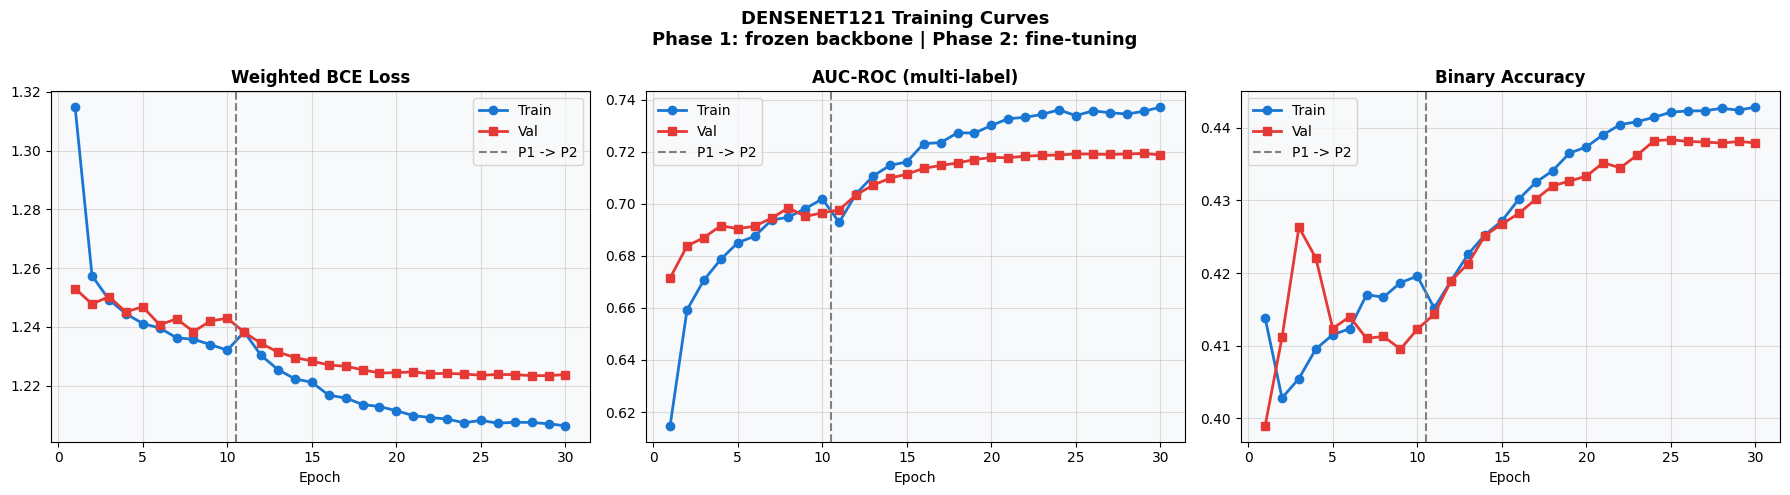

Saved: /kaggle/working/fig_densenet121_curves.png


In [10]:
def merge(h1, h2, k):
    return h1.history.get(k, []) + h2.history.get(k, [])

ep1 = len(h1.history['loss'])
tot = ep1 + len(h2.history['loss'])
x   = list(range(1, tot + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(MODEL_NAME.upper() + ' Training Curves\n'
             'Phase 1: frozen backbone | Phase 2: fine-tuning',
             fontsize=13, fontweight='bold')

for ax, (tk, vk, title) in zip(axes, [
    ('loss', 'val_loss', 'Weighted BCE Loss'),
    ('auc',  'val_auc',  'AUC-ROC (multi-label)'),
    ('acc',  'val_acc',  'Binary Accuracy')
]):
    ax.plot(x, merge(h1, h2, tk), 'o-', color='#1976D2', label='Train', lw=2)
    ax.plot(x, merge(h1, h2, vk), 's-', color='#E53935', label='Val',   lw=2)
    ax.axvline(ep1 + 0.5, color='gray', linestyle='--', lw=1.5, label='P1 -> P2')
    ax.set_xlabel('Epoch'); ax.set_title(title, fontweight='bold'); ax.legend()

plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 11. Evaluation — AUC-ROC Per Label

Best checkpoint weights loaded. AUC-ROC computed on test set (N=5,000) and gold set (N=234, radiologist-annotated).

In [11]:
model.load_weights(CKPT)
print('Best weights loaded from:', CKPT)


def predict(ds):
    yt, yp = [], []
    for imgs, labs in ds:
        yt.append(labs.numpy())
        yp.append(model(imgs, training=False).numpy())
    return np.vstack(yt), np.vstack(yp)


def calc_aucs(y_true, y_pred):
    r = {}
    for i, c in enumerate(LABEL_COLS):
        r[c] = float(roc_auc_score(y_true[:,i], y_pred[:,i])) \
               if int(y_true[:,i].sum()) >= 2 else float('nan')
    valid = [v for v in r.values() if not np.isnan(v)]
    r['MEAN_AUC'] = float(np.mean(valid))
    return r


print('Inference on test set...')
yt_test, yp_test = predict(test_ds)
print('Inference on gold set...')
yt_gold, yp_gold = predict(gold_ds)

auc_test = calc_aucs(yt_test, yp_test)
auc_gold = calc_aucs(yt_gold, yp_gold)

print()
print('Pathology'.ljust(35), 'Test AUC'.rjust(10), 'Gold AUC'.rjust(10))
print('-' * 60)
for col in LABEL_COLS:
    t = auc_test.get(col, float('nan'))
    g = auc_gold.get(col, float('nan'))
    print(col.ljust(35),
          ('-' if np.isnan(t) else str(round(t,4))).rjust(10),
          ('-' if np.isnan(g) else str(round(g,4))).rjust(10))
print('-' * 60)
print('MEAN AUC'.ljust(35),
      str(round(auc_test['MEAN_AUC'],4)).rjust(10),
      str(round(auc_gold['MEAN_AUC'],4)).rjust(10))

Best weights loaded from: /kaggle/working/densenet121_best.h5
Inference on test set...
Inference on gold set...

Pathology                             Test AUC   Gold AUC
------------------------------------------------------------
No Finding                              0.8595     0.8179
Enlarged Cardiomediastinum              0.6094     0.5123
Cardiomegaly                            0.7386     0.7262
Lung Opacity                            0.6847     0.8567
Lung Lesion                             0.7163          -
Edema                                   0.7804     0.8757
Consolidation                           0.6862     0.8327
Pneumonia                               0.6851     0.5973
Atelectasis                             0.6508     0.7903
Pneumothorax                             0.778     0.6963
Pleural Effusion                        0.7926     0.8374
Pleural Other                           0.6862          -
Fracture                                0.6938          -
Support Device

---
## 12. Per-Label AUC Visualisation

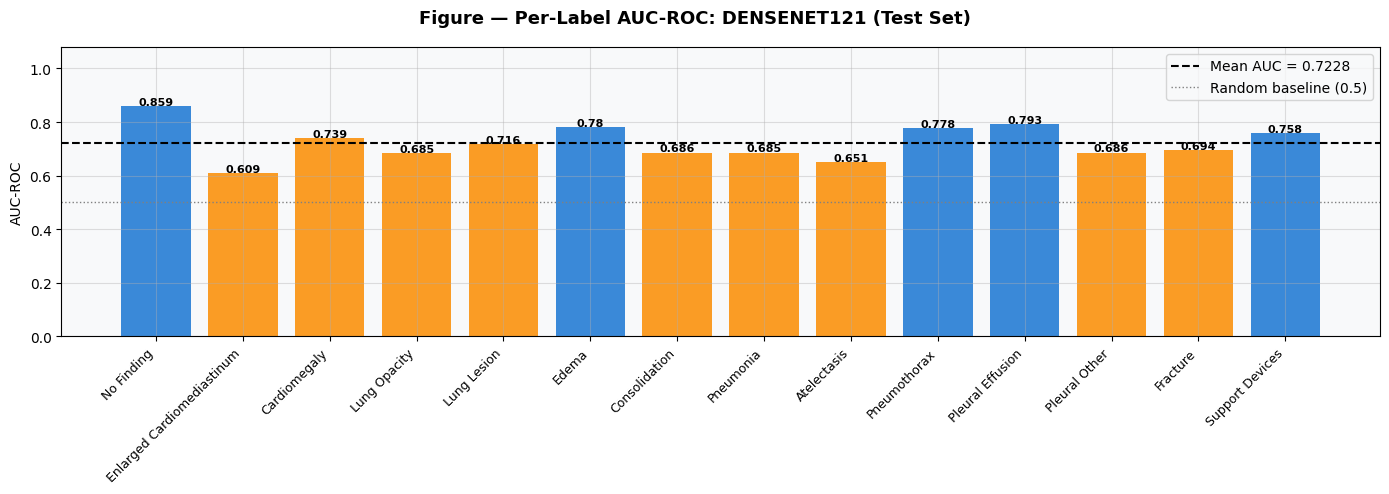

Saved: /kaggle/working/fig_densenet121_auc.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
vals   = [auc_test.get(c, 0.0) for c in LABEL_COLS]
colors = ['#1976D2' if v >= 0.75 else '#FB8C00' if v >= 0.60 else '#E53935'
          for v in vals]
bars = ax.bar(LABEL_COLS, vals, color=colors, alpha=0.85)
ax.axhline(auc_test['MEAN_AUC'], color='black', lw=1.5, linestyle='--',
           label='Mean AUC = ' + str(round(auc_test['MEAN_AUC'], 4)))
ax.axhline(0.5, color='gray', lw=1, linestyle=':', label='Random baseline (0.5)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            str(round(v,3)), ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(LABEL_COLS)))
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1.08); ax.legend(fontsize=10)
fig.suptitle('Figure — Per-Label AUC-ROC: ' + MODEL_NAME.upper() + ' (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_auc.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 13. Save Results

In [13]:
results = {
    'model': MODEL_NAME,
    'auc_test': {},
    'auc_gold': {},
    'config': {
        'epochs_p1': EPOCHS_P1, 'epochs_p2': EPOCHS_P2,
        'lr_p1': LR_P1, 'lr_p2': LR_P2,
        'es_patience': ES_PATIENCE,
        'label_smooth': LABEL_SMOOTH_EPS,
        'uncertainty': 'U-Mixed',
        'train_n': len(train_df), 'batch': BATCH_SIZE
    }
}

for col in LABEL_COLS + ['MEAN_AUC']:
    v = auc_test.get(col, float('nan'))
    results['auc_test'][col] = None if np.isnan(v) else round(v, 6)
    v = auc_gold.get(col, float('nan'))
    results['auc_gold'][col] = None if np.isnan(v) else round(v, 6)

out_j = os.path.join(OUT_DIR, MODEL_NAME + '_results.json')
with open(out_j, 'w') as f:
    json.dump(results, f, indent=2)

np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_test.npy'), yp_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_test.npy'), yt_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_gold.npy'), yp_gold)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_gold.npy'), yt_gold)

print('Results saved to:', OUT_DIR)
for fname in sorted(os.listdir(OUT_DIR)):
    if MODEL_NAME in fname:
        kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
        print(' ', fname, round(kb,1), 'KB')

Results saved to: /kaggle/working
  densenet121_best.h5 49133.5 KB
  densenet121_p1.csv 1.4 KB
  densenet121_p2.csv 2.8 KB
  densenet121_results.json 1.1 KB
  densenet121_ypred_gold.npy 12.9 KB
  densenet121_ypred_test.npy 273.6 KB
  densenet121_ytrue_gold.npy 12.9 KB
  densenet121_ytrue_test.npy 273.6 KB
  fig_densenet121_auc.png 116.0 KB
  fig_densenet121_curves.png 142.0 KB


---
## 14. Summary

In [14]:
print('=' * 62)
print('  NOTEBOOK 3B — DenseNet121 SUMMARY')
print('=' * 62)
print('  Architecture : DenseNet121')
print('  Key property : Dense connectivity — feature reuse')
print('  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)')
print()
print('  Training [identical config to all NB03 notebooks]')
print('    P1 :', EPOCHS_P1, 'epochs | backbone frozen | lr =', LR_P1)
print('    P2 : up to', EPOCHS_P2, 'epochs | last 80 layers unfrozen | lr =', LR_P2)
print('    EarlyStopping patience :', ES_PATIENCE)
print('    Label smoothing eps    :', LABEL_SMOOTH_EPS)
print('    Uncertainty strategy   : U-Mixed')
print('    Train N                :', len(train_df))
print()
print('  Results')
print('    Mean AUC (Test) :', round(auc_test['MEAN_AUC'],4))
print('    Mean AUC (Gold) :', round(auc_gold['MEAN_AUC'],4))
best = max([c for c in LABEL_COLS if not np.isnan(auc_test.get(c,float('nan')))],
           key=lambda c: auc_test[c])
print('    Best label      :', best, '=', round(auc_test[best],4))
print('=' * 62)

  NOTEBOOK 3B — DenseNet121 SUMMARY
  Architecture : DenseNet121
  Key property : Dense connectivity — feature reuse
  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)

  Training [identical config to all NB03 notebooks]
    P1 : 10 epochs | backbone frozen | lr = 0.001
    P2 : up to 20 epochs | last 80 layers unfrozen | lr = 1e-05
    EarlyStopping patience : 8
    Label smoothing eps    : 0.05
    Uncertainty strategy   : U-Mixed
    Train N                : 50000

  Results
    Mean AUC (Test) : 0.7228
    Mean AUC (Gold) : 0.7532
    Best label      : No Finding = 0.8595


---

## References

1. Huang, G., Liu, Z., van der Maaten, L., & Weinberger, K. Q. (2017). **Densely Connected Convolutional Networks.** *CVPR*, 4700–4708. https://doi.org/10.1109/CVPR.2017.243

2. Rajpurkar, P., et al. (2017). **CheXNet.** *arXiv:1711.05225.*

3. Irvin, J., et al. (2019). **CheXpert.** *AAAI*, 33(01), 590–597.

4. Szegedy, C., et al. (2016). **Label Smoothing.** *CVPR*, 2818–2826.

5. Loshchilov, I., & Hutter, F. (2017). **Cosine Annealing.** *ICLR.*